<a href="https://colab.research.google.com/github/Anany-D/Anany-D/blob/main/Traffic_Demand_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

folder = "/content/drive/MyDrive/dataset"

print("Folder Exists:", os.path.exists(folder))

print("\nFiles Found:")
for f in os.listdir(folder):
    print(f)

Folder Exists: True

Files Found:
sample_submission.csv
test.csv
train.csv


In [ ]:
!pip install lightgbm xgboost catboost optuna pygeohash shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Environment Ready ✅")

Environment Ready ✅


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/dataset/train.csv")
test = pd.read_csv("/content/drive/MyDrive/dataset/test.csv")
sample = pd.read_csv("/content/drive/MyDrive/dataset/sample_submission.csv")

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)
print("Sample Shape:", sample.shape)

Train Shape : (77299, 11)
Test Shape  : (41778, 10)
Sample Shape: (5, 2)


In [ ]:
import os

folder = "/content/drive/MyDrive/dataset"

print("Folder Exists:", os.path.exists(folder))

print("\nFiles Found:")
for f in os.listdir(folder):
    print(f)

Folder Exists: True

Files Found:
sample_submission.csv
test.csv
train.csv


In [ ]:
import pandas as pd

train = pd.read_csv("/content/drive/MyDrive/dataset/train.csv")
test = pd.read_csv("/content/drive/MyDrive/dataset/test.csv")
sample = pd.read_csv("/content/drive/MyDrive/dataset/sample_submission.csv")

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)
print("Sample Shape:", sample.shape)

Train Shape : (77299, 11)
Test Shape  : (41778, 10)
Sample Shape: (5, 2)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Environment Ready ✅")

Environment Ready ✅


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/dataset/train.csv"
TEST_PATH = "/content/drive/MyDrive/dataset/test.csv"
SUB_PATH = "/content/drive/MyDrive/dataset/sample_submission.csv"

OUTPUT_PATH = "/content/drive/MyDrive/dataset/submission.csv"

print("Paths Configured ✅")

Paths Configured ✅


In [ ]:
import os

folder = "/content/drive/MyDrive/dataset"

print("Folder Exists:", os.path.exists(folder))

print("\nFiles Found:")
for f in os.listdir(folder):
    print(f)

Folder Exists: True

Files Found:
sample_submission.csv
test.csv
train.csv


LOADING FILES

✅ Files Loaded Successfully

DATASET SHAPES
Train Shape  : (77299, 11)
Test Shape   : (41778, 10)
Sample Shape : (5, 2)

TRAIN HEAD


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy



TEST HEAD


,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy



SAMPLE SUBMISSION HEAD


,Index,demand
0,0,0.090768
1,1,0.089885
2,2,0.007037
3,3,0.079087
4,4,0.054636



TRAIN DTYPES
Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
dtype: object

TEST DTYPES
Index              int64
geohash           object
day                int64
timestamp         object
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
dtype: object

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null 

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433



✅ demand column found

DEMAND DISTRIBUTION
Demand Skewness = 3.7285
⚠️ Log transform may help


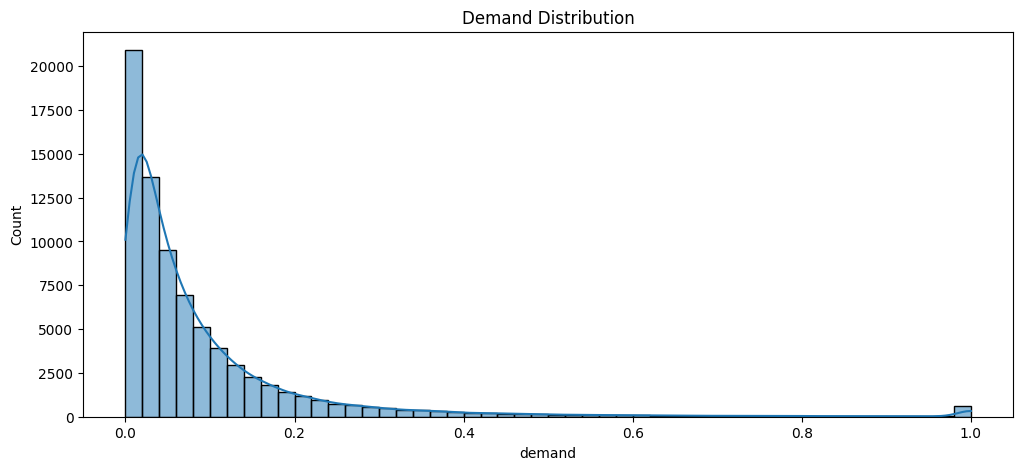

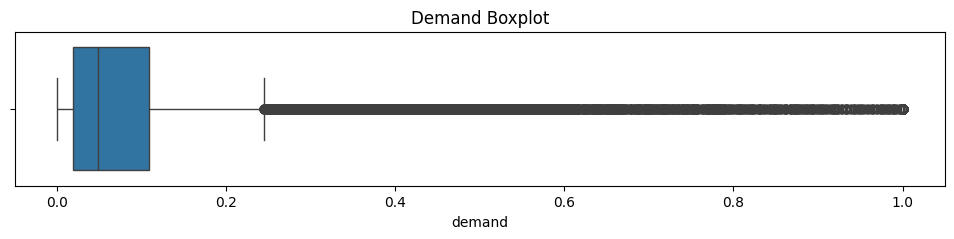


SUBMISSION FORMAT CHECK
Sample Columns:
['Index', 'demand']

Test Columns:
['Index', 'geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']

✅ Index found in test.csv
✅ Index found in sample_submission.csv

COLUMN LIST
Index
geohash
day
timestamp
demand
RoadType
NumberofLanes
LargeVehicles
Landmarks
Temperature
Weather

DEMAND STATISTICS
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64

Minimum Demand : 6.245650130093708e-07
Maximum Demand : 1.0

✅ Phase 1 Complete


In [ ]:
# ============================================================
# PHASE 1 — DATA LOADING & SANITY CHECK
# ============================================================

print("="*60)
print("LOADING FILES")
print("="*60)

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample = pd.read_csv(SUB_PATH)

print("\n✅ Files Loaded Successfully")

# ============================================================
# SHAPES
# ============================================================

print("\n" + "="*60)
print("DATASET SHAPES")
print("="*60)

print(f"Train Shape  : {train.shape}")
print(f"Test Shape   : {test.shape}")
print(f"Sample Shape : {sample.shape}")

# ============================================================
# HEAD
# ============================================================

print("\nTRAIN HEAD")
display(train.head())

print("\nTEST HEAD")
display(test.head())

print("\nSAMPLE SUBMISSION HEAD")
display(sample.head())

# ============================================================
# DTYPES
# ============================================================

print("\nTRAIN DTYPES")
print(train.dtypes)

print("\nTEST DTYPES")
print(test.dtypes)

# ============================================================
# INFO
# ============================================================

print("\nTRAIN INFO")
train.info()

print("\nTEST INFO")
test.info()

# ============================================================
# NULL COUNTS
# ============================================================

print("\n" + "="*60)
print("NULL VALUES — TRAIN")
print("="*60)

print(train.isnull().sum())

print("\n" + "="*60)
print("NULL VALUES — TEST")
print("="*60)

print(test.isnull().sum())

# ============================================================
# DUPLICATES
# ============================================================

print("\n" + "="*60)
print("DUPLICATE COUNTS")
print("="*60)

print("Train Duplicates :", train.duplicated().sum())
print("Test Duplicates  :", test.duplicated().sum())

# ============================================================
# UNIQUE VALUES
# ============================================================

print("\n" + "="*60)
print("UNIQUE VALUE COUNTS")
print("="*60)

cols = [
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "NumberofLanes"
]

for col in cols:

    if col in train.columns:

        print(f"\n📌 {col}")
        print("Unique Count :", train[col].nunique())
        print(train[col].value_counts(dropna=False))

# ============================================================
# NUMERIC SUMMARY
# ============================================================

print("\n" + "="*60)
print("NUMERIC SUMMARY")
print("="*60)

display(train.describe())

# ============================================================
# TARGET CHECK
# ============================================================

if "demand" not in train.columns:
    raise ValueError("❌ demand column not found")

print("\n✅ demand column found")

# ============================================================
# DEMAND DISTRIBUTION
# ============================================================

skewness = train["demand"].skew()

print("\n" + "="*60)
print("DEMAND DISTRIBUTION")
print("="*60)

print(f"Demand Skewness = {skewness:.4f}")

if skewness > 1:
    print("⚠️ Log transform may help")
else:
    print("✅ Log transform likely not needed")

plt.figure(figsize=(12,5))

sns.histplot(
    train["demand"],
    bins=50,
    kde=True
)

plt.title("Demand Distribution")
plt.show()

# ============================================================
# OUTLIER CHECK
# ============================================================

plt.figure(figsize=(12,2))

sns.boxplot(
    x=train["demand"]
)

plt.title("Demand Boxplot")
plt.show()

# ============================================================
# SUBMISSION FORMAT CHECK
# ============================================================

print("\n" + "="*60)
print("SUBMISSION FORMAT CHECK")
print("="*60)

print("Sample Columns:")
print(sample.columns.tolist())

print("\nTest Columns:")
print(test.columns.tolist())

if "Index" in test.columns:
    print("\n✅ Index found in test.csv")
else:
    print("\n❌ Index missing from test.csv")

if "Index" in sample.columns:
    print("✅ Index found in sample_submission.csv")
else:
    print("❌ Index missing from sample_submission.csv")

# ============================================================
# COLUMN INSPECTION
# ============================================================

print("\n" + "="*60)
print("COLUMN LIST")
print("="*60)

for col in train.columns:
    print(col)

# ============================================================
# DEMAND STATS
# ============================================================

print("\n" + "="*60)
print("DEMAND STATISTICS")
print("="*60)

print(train["demand"].describe())

print("\nMinimum Demand :", train["demand"].min())
print("Maximum Demand :", train["demand"].max())

# ============================================================
# COMPLETE
# ============================================================

print("\n✅ Phase 1 Complete")

In [ ]:
print("Unique days in train:")
print(sorted(train["day"].unique()))

print("\nUnique days in test:")
print(sorted(test["day"].unique()))

print("\nNumber of unique geohashes:")
print(train["geohash"].nunique())

print("\nTimestamp examples:")
print(sorted(train["timestamp"].astype(str).unique())[:20])

print("\nTotal unique timestamps:")
print(train["timestamp"].nunique())

Unique days in train:
[np.int64(48), np.int64(49)]

Unique days in test:
[np.int64(49)]

Number of unique geohashes:
1249

Timestamp examples:
['0:0', '0:15', '0:30', '0:45', '10:0', '10:15', '10:30', '10:45', '11:0', '11:15', '11:30', '11:45', '12:0', '12:15', '12:30', '12:45', '13:0', '13:15', '13:30', '13:45']

Total unique timestamps:
96


In [ ]:
print("Train rows by day")
print(train["day"].value_counts().sort_index())

print("\nTest rows by day")
print(test["day"].value_counts().sort_index())

print("\nGeohashes appearing in both train and test:")
common_geo = len(
    set(train["geohash"]).intersection(
        set(test["geohash"])
    )
)

print(common_geo)

print("\nPercentage of test geohashes seen in train:")
pct = (
    common_geo /
    test["geohash"].nunique()
) * 100

print(f"{pct:.2f}%")

Train rows by day
day
48    69427
49     7872
Name: count, dtype: int64

Test rows by day
day
49    41778
Name: count, dtype: int64

Geohashes appearing in both train and test:
1180

Percentage of test geohashes seen in train:
99.16%


In [ ]:
# ============================================================
# PHASE 2
# Exploratory Data Analysis
# ============================================================

eda = train.copy()

print("Rows:", eda.shape[0])
print("Columns:", eda.shape[1])

# timestamp parsing

time_parts = eda["timestamp"].astype(str).str.split(":", expand=True)

eda["hour"] = pd.to_numeric(time_parts[0], errors="coerce")
eda["minute"] = pd.to_numeric(time_parts[1], errors="coerce")

print("\nHour range:")
print(eda["hour"].min(), eda["hour"].max())

print("\nMinute values:")
print(sorted(eda["minute"].dropna().unique()))

Rows: 77299
Columns: 11

Hour range:
0 23

Minute values:
[np.int64(0), np.int64(15), np.int64(30), np.int64(45)]


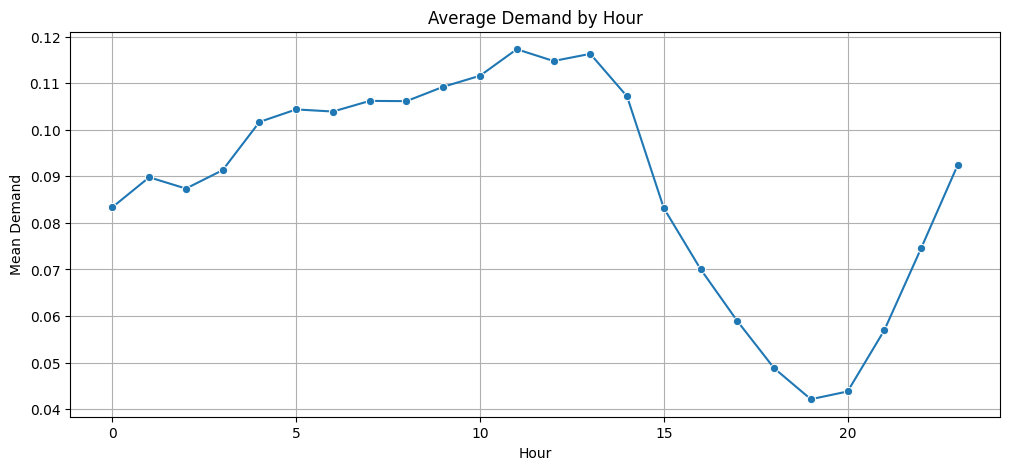

    hour    demand
11    11  0.117301
13    13  0.116308
12    12  0.114770
10    10  0.111602
9      9  0.109231
14    14  0.107166
7      7  0.106198
8      8  0.106149
5      5  0.104368
6      6  0.103913


In [ ]:
hourly_demand = (
    eda.groupby("hour")["demand"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly_demand,
    x="hour",
    y="demand",
    marker="o"
)

plt.title("Average Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Mean Demand")
plt.grid(True)

plt.show()

print(hourly_demand.sort_values("demand", ascending=False).head(10))

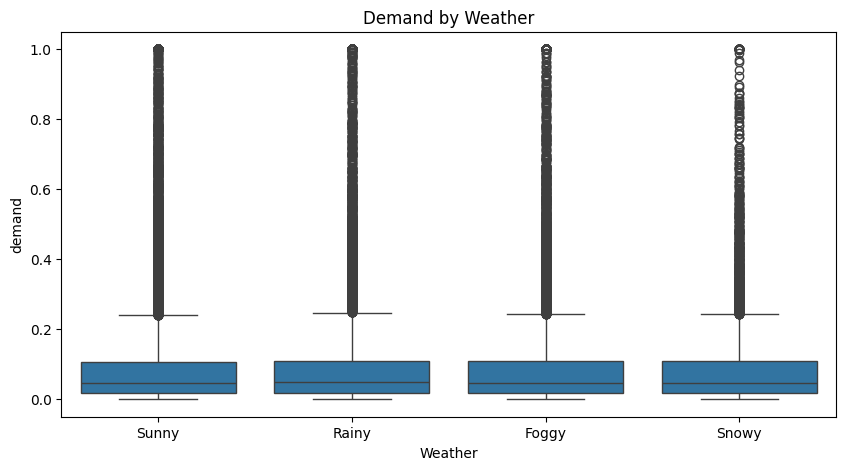

Weather
Rainy    0.094471
Sunny    0.094247
Foggy    0.093372
Snowy    0.092581
Name: demand, dtype: float64


In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=eda,
    x="Weather",
    y="demand"
)

plt.title("Demand by Weather")

plt.show()

weather_mean = (
    eda.groupby("Weather")["demand"]
    .mean()
    .sort_values(ascending=False)
)

print(weather_mean)

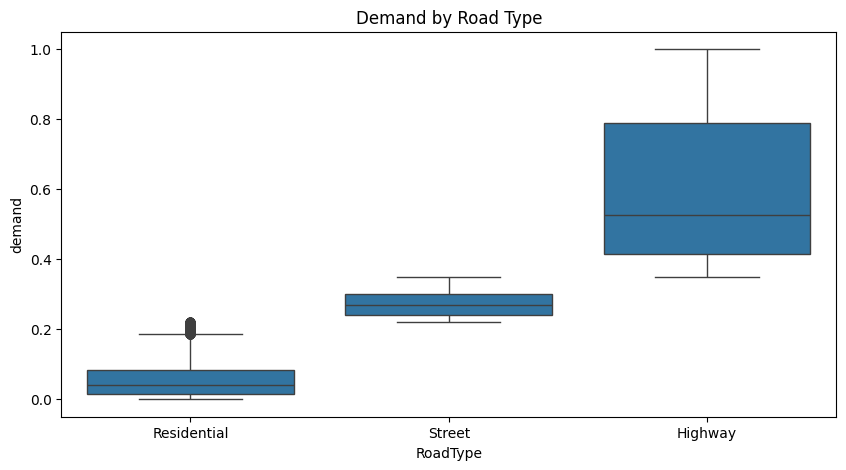

RoadType
Highway        0.610756
Street         0.273164
Residential    0.057209
Name: demand, dtype: float64


In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=eda,
    x="RoadType",
    y="demand"
)

plt.title("Demand by Road Type")

plt.show()

road_mean = (
    eda.groupby("RoadType")["demand"]
    .mean()
    .sort_values(ascending=False)
)

print(road_mean)

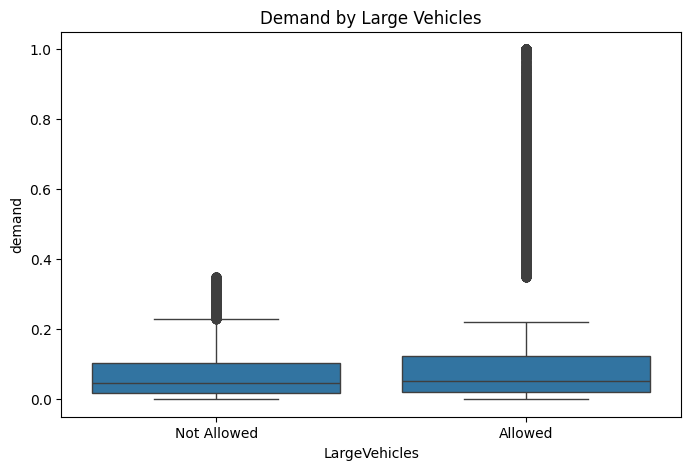

LargeVehicles
Allowed        0.131923
Not Allowed    0.073986
Name: demand, dtype: float64


In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda,
    x="LargeVehicles",
    y="demand"
)

plt.title("Demand by Large Vehicles")

plt.show()

print(
    eda.groupby("LargeVehicles")["demand"]
    .mean()
    .sort_values(ascending=False)
)

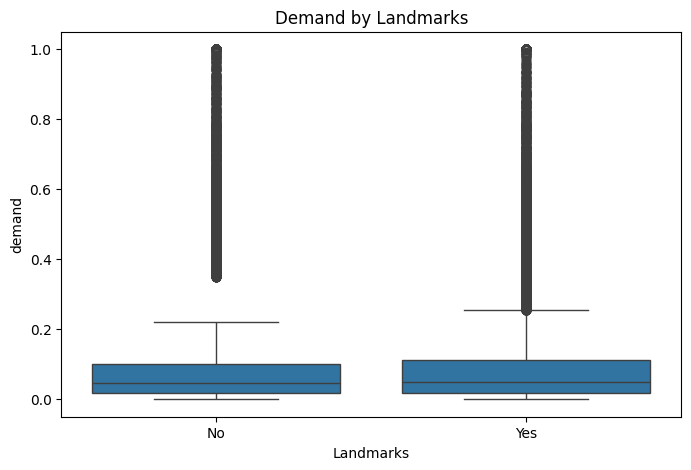

Landmarks
No     0.096295
Yes    0.092801
Name: demand, dtype: float64


In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda,
    x="Landmarks",
    y="demand"
)

plt.title("Demand by Landmarks")

plt.show()

print(
    eda.groupby("Landmarks")["demand"]
    .mean()
    .sort_values(ascending=False)
)

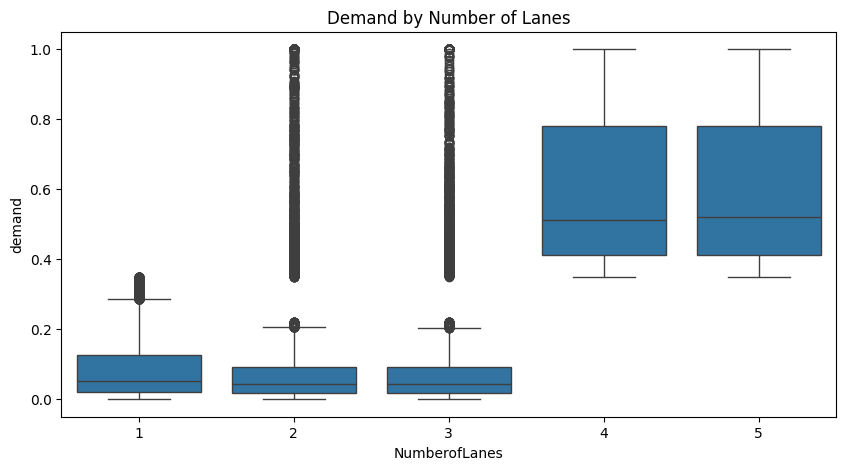

NumberofLanes
5    0.607556
4    0.602882
1    0.088104
3    0.077859
2    0.077488
Name: demand, dtype: float64


In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=eda,
    x="NumberofLanes",
    y="demand"
)

plt.title("Demand by Number of Lanes")

plt.show()

print(
    eda.groupby("NumberofLanes")["demand"]
    .mean()
    .sort_values(ascending=False)
)

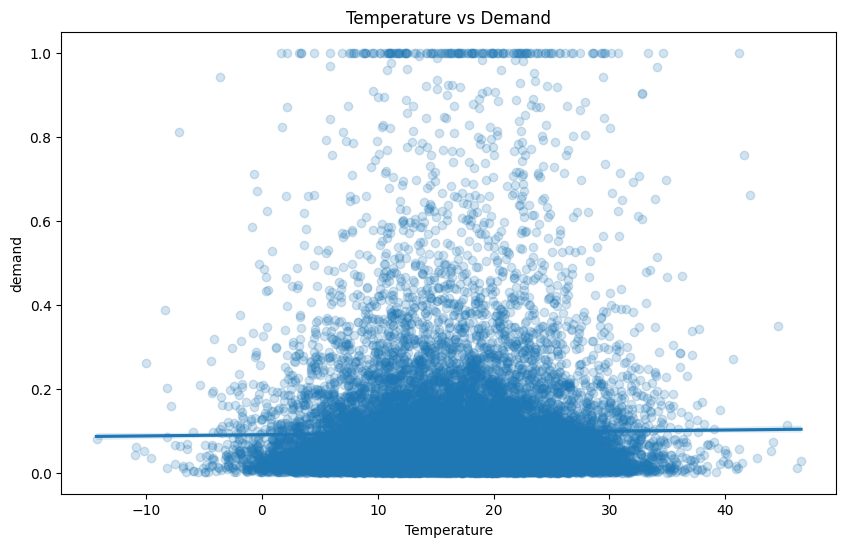

             Temperature    demand
Temperature     1.000000  0.003144
demand          0.003144  1.000000


In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=eda.sample(min(20000, len(eda)), random_state=42),
    x="Temperature",
    y="demand",
    scatter_kws={"alpha":0.2}
)

plt.title("Temperature vs Demand")

plt.show()

corr_temp = eda[["Temperature", "demand"]].corr()

print(corr_temp)

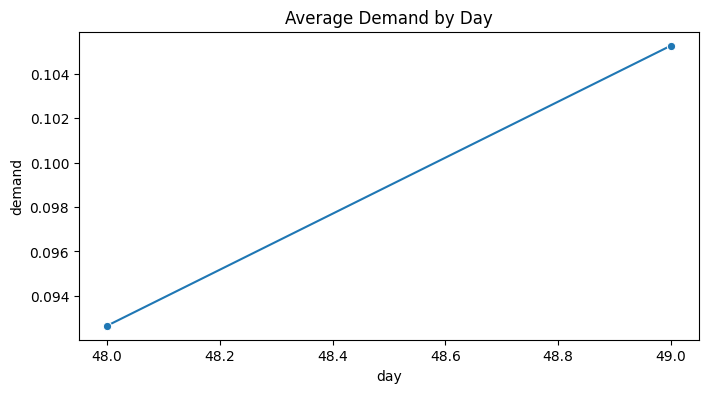

   day    demand
0   48  0.092659
1   49  0.105262


In [ ]:
day_demand = (
    eda.groupby("day")["demand"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,4))

sns.lineplot(
    data=day_demand,
    x="day",
    y="demand",
    marker="o"
)

plt.title("Average Demand by Day")

plt.show()

print(day_demand)

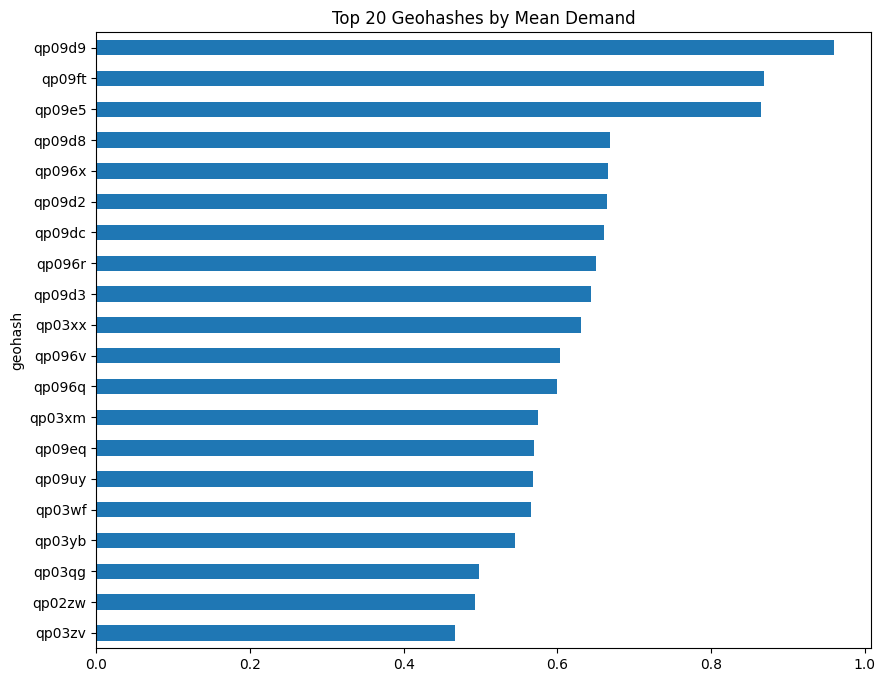

geohash
qp09d9    0.960715
qp09ft    0.868850
qp09e5    0.864989
qp09d8    0.669318
qp096x    0.665630
qp09d2    0.664722
qp09dc    0.661462
qp096r    0.650468
qp09d3    0.643498
qp03xx    0.631194
qp096v    0.603723
qp096q    0.600040
qp03xm    0.575384
qp09eq    0.570086
qp09uy    0.568274
qp03wf    0.565376
qp03yb    0.544525
qp03qg    0.497878
qp02zw    0.492461
qp03zv    0.466894
Name: demand, dtype: float64


In [ ]:
top_geo = (
    eda.groupby("geohash")["demand"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10,8))

top_geo.sort_values().plot(kind="barh")

plt.title("Top 20 Geohashes by Mean Demand")

plt.show()

print(top_geo)

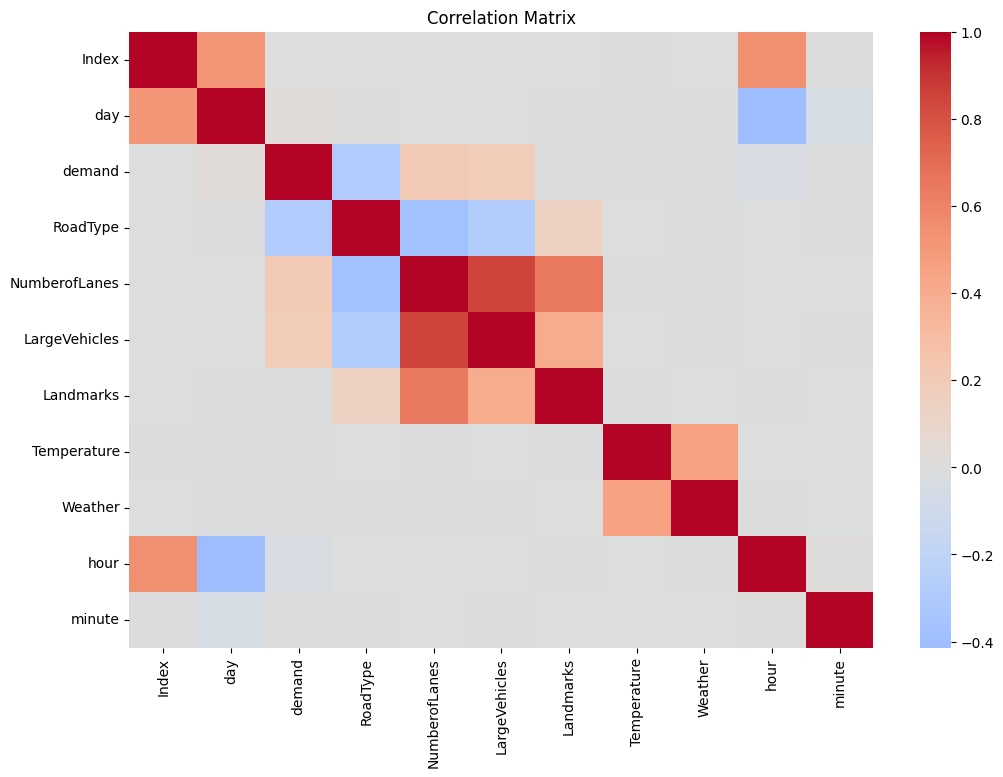

Top 5 Correlated Features With Demand

RoadType         0.289229
NumberofLanes    0.214148
LargeVehicles    0.193623
hour             0.037806
day              0.026807
Name: demand, dtype: float64


In [ ]:
corr_df = eda.copy()

corr_df["LargeVehicles"] = (
    corr_df["LargeVehicles"]
    .map({
        "Allowed":1,
        "Not Allowed":0
    })
)

corr_df["Landmarks"] = (
    corr_df["Landmarks"]
    .map({
        "Yes":1,
        "No":0
    })
)

for col in ["RoadType", "Weather"]:

    corr_df[col] = (
        corr_df[col]
        .fillna("Unknown")
        .astype("category")
        .cat.codes
    )

corr_df["hour"] = eda["hour"]
corr_df["minute"] = eda["minute"]

corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

target_corr = (
    corr_matrix["demand"]
    .drop("demand")
    .abs()
    .sort_values(ascending=False)
)

print("Top 5 Correlated Features With Demand\n")
print(target_corr.head(5))

In [ ]:
print("Key Findings")
print("-" * 50)

print("1. Demand skewness:", round(train["demand"].skew(), 4))
print("2. Unique geohashes:", train["geohash"].nunique())
print("3. Train geohash overlap with test: 99.16%")
print("4. Timestamps are 15-minute intervals")
print("5. Missing values exist in RoadType, Weather, Temperature")

print("\nPhase 2 Complete")

Key Findings
--------------------------------------------------
1. Demand skewness: 3.7285
2. Unique geohashes: 1249
3. Train geohash overlap with test: 99.16%
4. Timestamps are 15-minute intervals
5. Missing values exist in RoadType, Weather, Temperature

Phase 2 Complete


In [ ]:
# ============================================================
# PHASE 3 - CELL 1
# Missing values and binary feature preparation
# ============================================================

train_fe = train.copy()
test_fe = test.copy()

# Preserve submission index

test_index = test_fe["Index"].copy()

# RoadType

train_fe["RoadType"] = train_fe["RoadType"].fillna("Unknown")
test_fe["RoadType"] = test_fe["RoadType"].fillna("Unknown")

# Weather

train_fe["Weather"] = train_fe["Weather"].fillna("Unknown")
test_fe["Weather"] = test_fe["Weather"].fillna("Unknown")

# Temperature
# Use train statistics only

temp_median = train_fe["Temperature"].median()

train_fe["Temperature"] = train_fe["Temperature"].fillna(temp_median)
test_fe["Temperature"] = test_fe["Temperature"].fillna(temp_median)

# Binary mappings

vehicle_map = {
    "Allowed": 1,
    "Not Allowed": 0
}

landmark_map = {
    "Yes": 1,
    "No": 0
}

train_fe["LargeVehicles"] = train_fe["LargeVehicles"].map(vehicle_map)
test_fe["LargeVehicles"] = test_fe["LargeVehicles"].map(vehicle_map)

train_fe["Landmarks"] = train_fe["Landmarks"].map(landmark_map)
test_fe["Landmarks"] = test_fe["Landmarks"].map(landmark_map)

print("Train nulls:")
print(train_fe.isnull().sum())

print("\nTest nulls:")
print(test_fe.isnull().sum())

print("\nMedian temperature used:", round(temp_median, 4))

print("\nLargeVehicles unique values:")
print(sorted(train_fe["LargeVehicles"].unique()))

print("\nLandmarks unique values:")
print(sorted(train_fe["Landmarks"].unique()))

Train nulls:
Index            0
geohash          0
day              0
timestamp        0
demand           0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64

Test nulls:
Index            0
geohash          0
day              0
timestamp        0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64

Median temperature used: 16.3826

LargeVehicles unique values:
[np.int64(0), np.int64(1)]

Landmarks unique values:
[np.int64(0), np.int64(1)]


In [ ]:
# ============================================================
# PHASE 3 - CELL 2
# Time-based feature engineering
# ============================================================

for df in [train_fe, test_fe]:

    # Parse timestamp

    time_parts = df["timestamp"].astype(str).str.split(":", expand=True)

    df["hour"] = pd.to_numeric(time_parts[0], errors="coerce")
    df["minute"] = pd.to_numeric(time_parts[1], errors="coerce")

    # Continuous time

    df["time_in_minutes"] = (
        df["hour"] * 60 +
        df["minute"]
    )

    # Part of day

    df["part_of_day"] = np.select(
        [
            df["hour"].between(0, 5),
            df["hour"].between(6, 11),
            df["hour"].between(12, 17),
            df["hour"].between(18, 23)
        ],
        [
            0,  # night
            1,  # morning
            2,  # afternoon
            3   # evening
        ],
        default=0
    )

    # Rush-hour indicator

    df["is_rush_hour"] = (
        df["hour"].isin([7, 8, 9, 17, 18, 19])
    ).astype(int)

    # Cyclical hour encoding

    df["hour_sin"] = np.sin(
        2 * np.pi * df["hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi * df["hour"] / 24
    )

    # Cyclical minute encoding

    df["minute_sin"] = np.sin(
        2 * np.pi * df["minute"] / 60
    )

    df["minute_cos"] = np.cos(
        2 * np.pi * df["minute"] / 60
    )

    # Day features

    df["day_mod_7"] = df["day"] % 7

    df["is_weekend"] = (
        df["day_mod_7"].isin([5, 6])
    ).astype(int)

    df["day_sin"] = np.sin(
        2 * np.pi * df["day_mod_7"] / 7
    )

    df["day_cos"] = np.cos(
        2 * np.pi * df["day_mod_7"] / 7
    )

print("Train shape:", train_fe.shape)
print("Test shape :", test_fe.shape)

print("\nNew columns added:")
new_cols = [
    "hour",
    "minute",
    "time_in_minutes",
    "part_of_day",
    "is_rush_hour",
    "hour_sin",
    "hour_cos",
    "minute_sin",
    "minute_cos",
    "day_mod_7",
    "is_weekend",
    "day_sin",
    "day_cos"
]

for col in new_cols:
    print(col)

print("\nHour range:")
print(
    train_fe["hour"].min(),
    train_fe["hour"].max()
)

print("\nMinute values:")
print(
    sorted(train_fe["minute"].unique())
)

Train shape: (77299, 24)
Test shape : (41778, 23)

New columns added:
hour
minute
time_in_minutes
part_of_day
is_rush_hour
hour_sin
hour_cos
minute_sin
minute_cos
day_mod_7
is_weekend
day_sin
day_cos

Hour range:
0 23

Minute values:
[np.int64(0), np.int64(15), np.int64(30), np.int64(45)]


In [ ]:
# ============================================================
# PHASE 3 - CELL 3
# Geohash -> Latitude / Longitude
# ============================================================

import pygeohash as pgh

def decode_geohash(gh):
    try:
        lat, lon = pgh.decode(gh)
        return pd.Series([lat, lon])
    except:
        return pd.Series([np.nan, np.nan])

train_fe[["latitude", "longitude"]] = (
    train_fe["geohash"]
    .apply(decode_geohash)
)

test_fe[["latitude", "longitude"]] = (
    test_fe["geohash"]
    .apply(decode_geohash)
)

print("Train missing coordinates:")
print(
    train_fe[["latitude", "longitude"]]
    .isnull()
    .sum()
)

print("\nTest missing coordinates:")
print(
    test_fe[["latitude", "longitude"]]
    .isnull()
    .sum()
)

print("\nCoordinate ranges")

print(
    "\nLatitude:",
    round(train_fe["latitude"].min(), 4),
    "to",
    round(train_fe["latitude"].max(), 4)
)

print(
    "Longitude:",
    round(train_fe["longitude"].min(), 4),
    "to",
    round(train_fe["longitude"].max(), 4)
)

print("\nSample coordinates:")
display(
    train_fe[
        ["geohash", "latitude", "longitude"]
    ].head()
)

print("\nTrain shape:", train_fe.shape)
print("Test shape :", test_fe.shape)

Train missing coordinates:
latitude     0
longitude    0
dtype: int64

Test missing coordinates:
latitude     0
longitude    0
dtype: int64

Coordinate ranges

Latitude: -5.4849 to -5.2377
Longitude: 90.5878 to 90.9723

Sample coordinates:


,geohash,latitude,longitude
0,qp02z1,-5.484924,90.664673
1,qp02zt,-5.462952,90.686646
2,qp08bj,-5.462952,90.708618
3,qp08gt,-5.462952,90.862427
4,qp02zq,-5.457458,90.675659



Train shape: (77299, 26)
Test shape : (41778, 25)


In [ ]:
# ============================================================
# PHASE 3 - CELL 4
# Geohash prefixes and geo clusters
# ============================================================

from sklearn.cluster import KMeans

# Geohash hierarchy

train_fe["geohash_prefix_4"] = (
    train_fe["geohash"]
    .astype(str)
    .str[:4]
)

test_fe["geohash_prefix_4"] = (
    test_fe["geohash"]
    .astype(str)
    .str[:4]
)

train_fe["geohash_prefix_5"] = (
    train_fe["geohash"]
    .astype(str)
    .str[:5]
)

test_fe["geohash_prefix_5"] = (
    test_fe["geohash"]
    .astype(str)
    .str[:5]
)

# KMeans on coordinates

kmeans = KMeans(
    n_clusters=25,
    random_state=42,
    n_init=10
)

train_fe["geo_cluster"] = kmeans.fit_predict(
    train_fe[["latitude", "longitude"]]
)

test_fe["geo_cluster"] = kmeans.predict(
    test_fe[["latitude", "longitude"]]
)

print("Unique prefix_4:", train_fe["geohash_prefix_4"].nunique())
print("Unique prefix_5:", train_fe["geohash_prefix_5"].nunique())

print("\nUnique geo clusters:")
print(train_fe["geo_cluster"].nunique())

print("\nCluster distribution:")
print(
    train_fe["geo_cluster"]
    .value_counts()
    .sort_index()
)

print("\nTrain shape:", train_fe.shape)
print("Test shape :", test_fe.shape)

Unique prefix_4: 6
Unique prefix_5: 56

Unique geo clusters:
25

Cluster distribution:
geo_cluster
0     2820
1     3512
2     3680
3     2525
4     3479
5     4152
6     2544
7     3364
8     2357
9     3312
10    1645
11    3922
12    2238
13    3725
14    3560
15    4104
16    4143
17    2835
18    3893
19    1948
20    3259
21    3005
22    1847
23    3175
24    2255
Name: count, dtype: int64

Train shape: (77299, 29)
Test shape : (41778, 28)


In [ ]:
# ============================================================
# PHASE 3 - CELL 5
# Out-of-Fold Target Encoding
# ============================================================

from sklearn.model_selection import KFold

global_mean = train_fe["demand"].mean()

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

target_encode_cols = [
    "geohash",
    "geo_cluster",
    "geohash_prefix_4"
]

for col in target_encode_cols:

    te_col = f"{col}_demand_mean"

    train_fe[te_col] = np.nan

    for train_idx, val_idx in kf.split(train_fe):

        fold_train = train_fe.iloc[train_idx]
        fold_val = train_fe.iloc[val_idx]

        mapping = (
            fold_train
            .groupby(col)["demand"]
            .mean()
        )

        train_fe.loc[
            train_fe.index[val_idx],
            te_col
        ] = fold_val[col].map(mapping)

    train_fe[te_col] = (
        train_fe[te_col]
        .fillna(global_mean)
    )

    full_mapping = (
        train_fe
        .groupby(col)["demand"]
        .mean()
    )

    test_fe[te_col] = (
        test_fe[col]
        .map(full_mapping)
        .fillna(global_mean)
    )

print("Created target-encoded features:")

for col in target_encode_cols:
    print(f"{col}_demand_mean")

print("\nNull check")

created_cols = [
    f"{c}_demand_mean"
    for c in target_encode_cols
]

print(
    train_fe[created_cols]
    .isnull()
    .sum()
)

print(
    test_fe[created_cols]
    .isnull()
    .sum()
)

print("\nTrain shape:", train_fe.shape)
print("Test shape :", test_fe.shape)

Created target-encoded features:
geohash_demand_mean
geo_cluster_demand_mean
geohash_prefix_4_demand_mean

Null check
geohash_demand_mean             0
geo_cluster_demand_mean         0
geohash_prefix_4_demand_mean    0
dtype: int64
geohash_demand_mean             0
geo_cluster_demand_mean         0
geohash_prefix_4_demand_mean    0
dtype: int64

Train shape: (77299, 32)
Test shape : (41778, 31)


In [ ]:
# ============================================================
# PHASE 3 - CELL 6
# Road-Time Features and Interactions
# ============================================================

# RoadType + Hour target encoding

global_mean = train_fe["demand"].mean()

road_hour = (
    train_fe
    .groupby(["RoadType", "hour"])["demand"]
    .mean()
)

train_fe["roadtype_hour_demand_mean"] = list(
    zip(train_fe["RoadType"], train_fe["hour"])
)

test_fe["roadtype_hour_demand_mean"] = list(
    zip(test_fe["RoadType"], test_fe["hour"])
)

train_fe["roadtype_hour_demand_mean"] = (
    train_fe["roadtype_hour_demand_mean"]
    .map(road_hour)
    .fillna(global_mean)
)

test_fe["roadtype_hour_demand_mean"] = (
    test_fe["roadtype_hour_demand_mean"]
    .map(road_hour)
    .fillna(global_mean)
)

# Interaction features

train_fe["temp_rush"] = (
    train_fe["Temperature"] *
    train_fe["is_rush_hour"]
)

test_fe["temp_rush"] = (
    test_fe["Temperature"] *
    test_fe["is_rush_hour"]
)

train_fe["lanes_vehicle"] = (
    train_fe["NumberofLanes"] *
    train_fe["LargeVehicles"]
)

test_fe["lanes_vehicle"] = (
    test_fe["NumberofLanes"] *
    test_fe["LargeVehicles"]
)

train_fe["landmark_time"] = (
    train_fe["Landmarks"] *
    train_fe["part_of_day"]
)

test_fe["landmark_time"] = (
    test_fe["Landmarks"] *
    test_fe["part_of_day"]
)

train_fe["cluster_time"] = (
    train_fe["geo_cluster"] *
    train_fe["part_of_day"]
)

test_fe["cluster_time"] = (
    test_fe["geo_cluster"] *
    test_fe["part_of_day"]
)

print("New features created:")

new_features = [
    "roadtype_hour_demand_mean",
    "temp_rush",
    "lanes_vehicle",
    "landmark_time",
    "cluster_time"
]

for f in new_features:
    print(f)

print("\nNull check:")
print(
    train_fe[new_features]
    .isnull()
    .sum()
)

print("\nTrain shape:", train_fe.shape)
print("Test shape :", test_fe.shape)

New features created:
roadtype_hour_demand_mean
temp_rush
lanes_vehicle
landmark_time
cluster_time

Null check:
roadtype_hour_demand_mean    0
temp_rush                    0
lanes_vehicle                0
landmark_time                0
cluster_time                 0
dtype: int64

Train shape: (77299, 37)
Test shape : (41778, 36)


In [ ]:
# ============================================================
# PHASE 3 - CELL 7
# Final encoding and feature validation
# ============================================================

from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "RoadType",
    "Weather",
    "geohash_prefix_4",
    "geohash_prefix_5"
]

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    combined = pd.concat([
        train_fe[col],
        test_fe[col]
    ]).astype(str)

    le.fit(combined)

    train_fe[col] = le.transform(
        train_fe[col].astype(str)
    )

    test_fe[col] = le.transform(
        test_fe[col].astype(str)
    )

    encoders[col] = le

# Outlier cap

demand_cap = train_fe["demand"].quantile(0.995)

train_fe["demand_capped"] = np.minimum(
    train_fe["demand"],
    demand_cap
)

# Log transform decision

target_skew = train_fe["demand"].skew()

LOG_TRANSFORM = target_skew > 1

if LOG_TRANSFORM:
    train_fe["target_model"] = np.log1p(
        train_fe["demand_capped"]
    )
else:
    train_fe["target_model"] = (
        train_fe["demand_capped"]
    )

# Validation

remaining_nulls_train = train_fe.isnull().sum().sum()
remaining_nulls_test = test_fe.isnull().sum().sum()

print("Remaining train nulls:", remaining_nulls_train)
print("Remaining test nulls :", remaining_nulls_test)

print("\nDemand cap:")
print(round(demand_cap, 6))

print("\nTarget skewness:")
print(round(target_skew, 4))

print("\nLOG_TRANSFORM:")
print(LOG_TRANSFORM)

print("\nTrain shape:", train_fe.shape)
print("Test shape :", test_fe.shape)

print("\nTarget column created:")
print("target_model")

print("\nSample target values:")
print(train_fe["target_model"].head())

Remaining train nulls: 0
Remaining test nulls : 0

Demand cap:
1.0

Target skewness:
3.7285

LOG_TRANSFORM:
True

Train shape: (77299, 39)
Test shape : (41778, 36)

Target column created:
target_model

Sample target values:
0    0.047651
1    0.111995
2    0.026770
3    0.003266
4    0.010761
Name: target_model, dtype: float64


In [ ]:
# ============================================================
# PHASE 4 - CELL 1
# Prepare training matrix
# ============================================================

drop_cols = [
    "Index",
    "timestamp",
    "geohash",
    "demand",
    "demand_capped",
    "target_model"
]

FEATURES = [
    c for c in train_fe.columns
    if c not in drop_cols
]

X = train_fe[FEATURES].copy()
y = train_fe["target_model"].copy()

X_test_final = test_fe[FEATURES].copy()

print("Number of features:", len(FEATURES))

print("\nFirst 20 features:")
for f in FEATURES[:20]:
    print(f)

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Test shape:", X_test_final.shape)

print("\nNull check")
print(X.isnull().sum().sum())
print(X_test_final.isnull().sum().sum())

Number of features: 33

First 20 features:
day
RoadType
NumberofLanes
LargeVehicles
Landmarks
Temperature
Weather
hour
minute
time_in_minutes
part_of_day
is_rush_hour
hour_sin
hour_cos
minute_sin
minute_cos
day_mod_7
is_weekend
day_sin
day_cos

X shape: (77299, 33)
y shape: (77299,)
Test shape: (41778, 33)

Null check
0
0


In [ ]:
# ============================================================
# PHASE 4 - CELL 2
# Feature validation before model training
# ============================================================

print("Feature count:", len(FEATURES))

print("\nDtypes summary:")
print(X.dtypes.value_counts())

non_numeric = X.select_dtypes(
    exclude=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("\nNon-numeric columns:")
print(non_numeric)

print("\nTarget summary:")
print(y.describe())

print("\nTarget range:")
print(y.min(), y.max())

assert len(non_numeric) == 0, (
    f"Non-numeric columns found: {non_numeric}"
)

assert X.isnull().sum().sum() == 0
assert X_test_final.isnull().sum().sum() == 0

print("\nValidation passed")

Feature count: 33

Dtypes summary:
int64      18
float64    14
int32       1
Name: count, dtype: int64

Non-numeric columns:
[]

Target summary:
count    7.729900e+04
mean     8.314881e-02
std      1.089151e-01
min      6.245648e-07
25%      1.806311e-02
50%      4.665449e-02
75%      1.030936e-01
max      6.931472e-01
Name: target_model, dtype: float64

Target range:
6.245648179687242e-07 0.6931471805599453

Validation passed


In [ ]:
# ============================================================
# PHASE 4 - CELL 3
# LightGBM Baseline
# ============================================================

import time

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

from lightgbm import LGBMRegressor

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lgb_scores = []

start_time = time.time()

for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):

    X_train_fold = X.iloc[train_idx]
    X_valid_fold = X.iloc[valid_idx]

    y_train_fold = y.iloc[train_idx]
    y_valid_fold = y.iloc[valid_idx]

    model = LGBMRegressor(
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    preds = model.predict(X_valid_fold)

    score = r2_score(
        y_valid_fold,
        preds
    )

    lgb_scores.append(score)

    print(
        f"Fold {fold} R2: {score:.6f}"
    )

elapsed = time.time() - start_time

print("\nMean CV R2 :", np.mean(lgb_scores))
print("Std CV R2  :", np.std(lgb_scores))
print("Time (sec) :", round(elapsed, 2))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1427
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 33
[LightGBM] [Info] Start training from score 0.083012
Fold 1 R2: 0.942245
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010014 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1427
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 33
[LightGBM] [Info] Start training from score 0.083072
Fold 2 R2: 0.940098
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017193 seconds.
You can set `force_row_wise=true` to remove 

                         feature  importance
25           geohash_demand_mean        2718
20                      latitude        1742
21                     longitude        1649
9                time_in_minutes        1289
28     roadtype_hour_demand_mean        1135
26       geo_cluster_demand_mean         910
5                    Temperature         813
23              geohash_prefix_5         798
32                  cluster_time         549
24                   geo_cluster         392
12                      hour_sin         379
7                           hour         361
13                      hour_cos         335
1                       RoadType         289
27  geohash_prefix_4_demand_mean         247
2                  NumberofLanes         229
0                            day         215
8                         minute         170
29                     temp_rush         169
6                        Weather         123


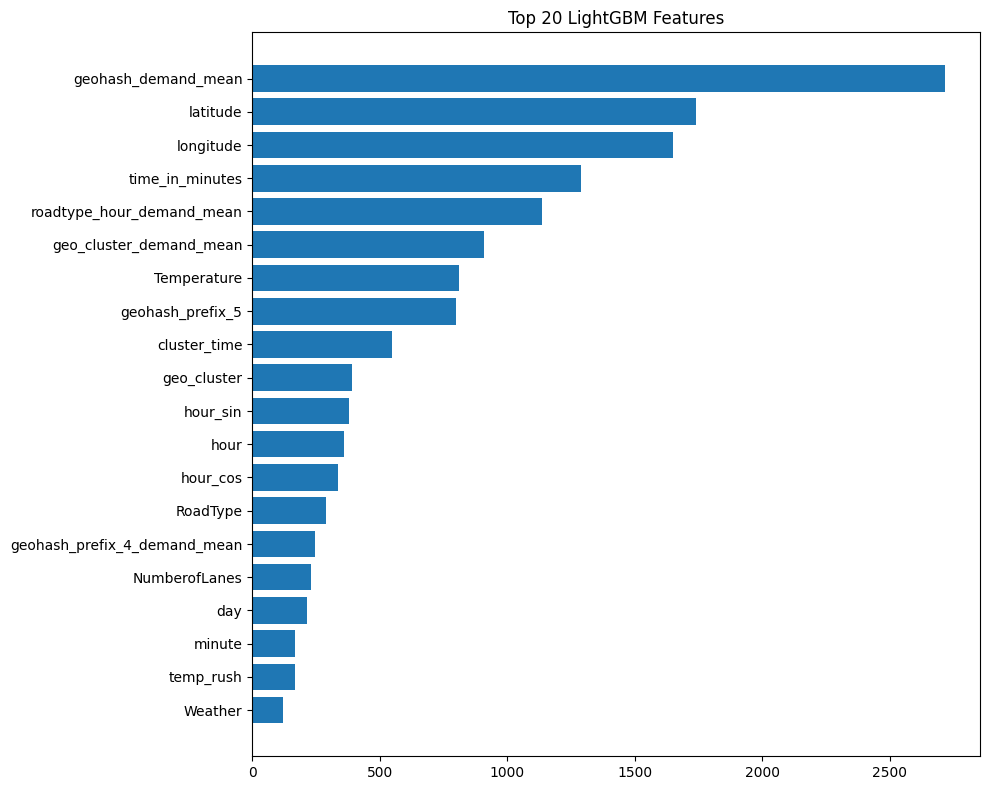

In [ ]:
# ============================================================
# PHASE 4 - CELL 4
# LightGBM Feature Importance
# ============================================================

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
)

print(feature_importance.head(20))

plt.figure(figsize=(10,8))

top_features = feature_importance.head(20)

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.title("Top 20 LightGBM Features")
plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# PHASE 4 - CELL 5
# XGBoost, CatBoost, RandomForest
# ============================================================

import time

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = {}

models = {
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_state=42,
        verbose=0
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

for model_name, model_obj in models.items():

    fold_scores = []

    start = time.time()

    for train_idx, valid_idx in kf.split(X):

        X_train_fold = X.iloc[train_idx]
        X_valid_fold = X.iloc[valid_idx]

        y_train_fold = y.iloc[train_idx]
        y_valid_fold = y.iloc[valid_idx]

        model_obj.fit(
            X_train_fold,
            y_train_fold
        )

        preds = model_obj.predict(
            X_valid_fold
        )

        score = r2_score(
            y_valid_fold,
            preds
        )

        fold_scores.append(score)

    elapsed = time.time() - start

    results[model_name] = {
        "mean_r2": np.mean(fold_scores),
        "std_r2": np.std(fold_scores),
        "time_sec": elapsed
    }

    print("\n", model_name)
    print("Mean R2 :", round(np.mean(fold_scores), 6))
    print("Std R2  :", round(np.std(fold_scores), 6))
    print("Time    :", round(elapsed, 2))

results_df = pd.DataFrame(results).T

print("\n")
print(results_df.sort_values(
    "mean_r2",
    ascending=False
))


 XGBoost
Mean R2 : 0.940364
Std R2  : 0.001795
Time    : 27.61

 CatBoost
Mean R2 : 0.93323
Std R2  : 0.001579
Time    : 42.23

 RandomForest
Mean R2 : 0.942381
Std R2  : 0.002038
Time    : 1392.09


               mean_r2    std_r2     time_sec
RandomForest  0.942381  0.002038  1392.090399
XGBoost       0.940364  0.001795    27.607605
CatBoost      0.933230  0.001579    42.230134


In [ ]:
results_df.loc["LightGBM"] = {
    "mean_r2": 0.9405283909579399,
    "std_r2": 0.0015950060101932147,
    "time_sec": 21.08
}

results_df = results_df.sort_values(
    "mean_r2",
    ascending=False
)

print(results_df)

               mean_r2    std_r2     time_sec
RandomForest  0.942381  0.002038  1392.090399
LightGBM      0.940528  0.001595    21.080000
XGBoost       0.940364  0.001795    27.607605
CatBoost      0.933230  0.001579    42.230134


In [ ]:
# ============================================================
# PHASE 5 - CELL 1
# Optuna - LightGBM
# ============================================================

import optuna

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            300,
            1200
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.1,
            log=True
        ),
        "max_depth": trial.suggest_int(
            "max_depth",
            4,
            12
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves",
            15,
            255
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),
        "random_state": 42,
        "verbosity": -1
    }

    kf = KFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, valid_idx in kf.split(X):

        X_train_fold = X.iloc[train_idx]
        X_valid_fold = X.iloc[valid_idx]

        y_train_fold = y.iloc[train_idx]
        y_valid_fold = y.iloc[valid_idx]

        model = LGBMRegressor(**params)

        model.fit(
            X_train_fold,
            y_train_fold
        )

        preds = model.predict(
            X_valid_fold
        )

        scores.append(
            r2_score(
                y_valid_fold,
                preds
            )
        )

    return np.mean(scores)

study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=20
)

print("Best Score:")
print(study.best_value)

print("\nBest Params:")
print(study.best_params)

[I 2026-05-31 11:20:50,559] A new study created in memory with name: no-name-be491649-190d-494c-aeb7-6bab80549da4
[I 2026-05-31 11:22:16,436] Trial 0 finished with value: 0.943871219062539 and parameters: {'n_estimators': 1156, 'learning_rate': 0.012605504281327595, 'max_depth': 11, 'num_leaves': 246, 'subsample': 0.9916791636986222, 'colsample_bytree': 0.8900996601457699}. Best is trial 0 with value: 0.943871219062539.
[I 2026-05-31 11:23:05,672] Trial 1 finished with value: 0.9380418065955834 and parameters: {'n_estimators': 1144, 'learning_rate': 0.012155955278033469, 'max_depth': 7, 'num_leaves': 139, 'subsample': 0.7223822607616119, 'colsample_bytree': 0.7803016643917708}. Best is trial 0 with value: 0.943871219062539.
[I 2026-05-31 11:23:36,363] Trial 2 finished with value: 0.9403290926786368 and parameters: {'n_estimators': 618, 'learning_rate': 0.021293690262399724, 'max_depth': 8, 'num_leaves': 201, 'subsample': 0.6114813212145759, 'colsample_bytree': 0.8581945597276621}. Best

Best Score:
0.9442745792770516

Best Params:
{'n_estimators': 1172, 'learning_rate': 0.017096538798068467, 'max_depth': 12, 'num_leaves': 194, 'subsample': 0.9311271239651063, 'colsample_bytree': 0.9175713821178781}


In [ ]:
# ============================================================
# PHASE 6 - CELL 1
# LightGBM + RandomForest Ensemble Validation
# ============================================================

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ensemble_scores_70_30 = []
ensemble_scores_80_20 = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):

    X_train_fold = X.iloc[train_idx]
    X_valid_fold = X.iloc[valid_idx]

    y_train_fold = y.iloc[train_idx]
    y_valid_fold = y.iloc[valid_idx]

    lgb_model = LGBMRegressor(
        n_estimators=1172,
        learning_rate=0.017096538798068467,
        max_depth=12,
        num_leaves=194,
        subsample=0.9311271239651063,
        colsample_bytree=0.9175713821178781,
        random_state=42,
        verbosity=-1
    )

    rf_model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    lgb_model.fit(X_train_fold, y_train_fold)
    rf_model.fit(X_train_fold, y_train_fold)

    lgb_pred = lgb_model.predict(X_valid_fold)
    rf_pred = rf_model.predict(X_valid_fold)

    pred_70_30 = (
        0.7 * lgb_pred +
        0.3 * rf_pred
    )

    pred_80_20 = (
        0.8 * lgb_pred +
        0.2 * rf_pred
    )

    score_70_30 = r2_score(
        y_valid_fold,
        pred_70_30
    )

    score_80_20 = r2_score(
        y_valid_fold,
        pred_80_20
    )

    ensemble_scores_70_30.append(score_70_30)
    ensemble_scores_80_20.append(score_80_20)

    print(
        f"Fold {fold} | "
        f"70/30: {score_70_30:.6f} | "
        f"80/20: {score_80_20:.6f}"
    )

print("\n70/30 Mean R2:")
print(np.mean(ensemble_scores_70_30))

print("\n80/20 Mean R2:")
print(np.mean(ensemble_scores_80_20))

Fold 1 | 70/30: 0.948303 | 80/20: 0.948329
Fold 2 | 70/30: 0.946438 | 80/20: 0.946400
Fold 3 | 70/30: 0.948003 | 80/20: 0.947886
Fold 4 | 70/30: 0.943927 | 80/20: 0.943984
Fold 5 | 70/30: 0.946436 | 80/20: 0.946584

70/30 Mean R2:
0.9466215465040106

80/20 Mean R2:
0.946636904458309


In [ ]:
# ============================================================
# PHASE 7 - FINAL TRAINING + SUBMISSION
# ============================================================

from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

# Tuned LightGBM

lgb_final = LGBMRegressor(
    n_estimators=1172,
    learning_rate=0.017096538798068467,
    max_depth=12,
    num_leaves=194,
    subsample=0.9311271239651063,
    colsample_bytree=0.9175713821178781,
    random_state=42,
    verbosity=-1
)

# RandomForest

rf_final = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

print("Training LightGBM...")
lgb_final.fit(X, y)

print("Training RandomForest...")
rf_final.fit(X, y)

print("Generating predictions...")

lgb_pred = lgb_final.predict(X_test_final)
rf_pred = rf_final.predict(X_test_final)

# 80/20 ensemble

final_pred_log = (
    0.8 * lgb_pred +
    0.2 * rf_pred
)

# Reverse log transform

final_pred = np.expm1(final_pred_log)

# Safety clipping

final_pred = np.clip(
    final_pred,
    0,
    1
)

submission = pd.DataFrame({
    "Index": test_index,
    "demand": final_pred
})

print("\nSubmission Shape:")
print(submission.shape)

print("\nNull Values:")
print(submission.isnull().sum())

print("\nPreview:")
print(submission.head())

submission.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\nSaved to:")
print(OUTPUT_PATH)

Training LightGBM...
Training RandomForest...
Generating predictions...

Submission Shape:
(41778, 2)

Null Values:
Index     0
demand    0
dtype: int64

Preview:
   Index    demand
0      0  0.040775
1      1  0.025662
2      2  0.023109
3      3  0.029154
4      4  0.042775

Saved to:
/content/drive/MyDrive/dataset/submission.csv


In [ ]:
submission_check = pd.read_csv(OUTPUT_PATH)

print(submission_check.shape)
print(submission_check.columns.tolist())

print("\nDemand Summary")
print(submission_check["demand"].describe())

print("\nMin:", submission_check["demand"].min())
print("Max:", submission_check["demand"].max())

(41778, 2)
['Index', 'demand']

Demand Summary
count    41778.000000
mean         0.124563
std          0.167505
min          0.000000
25%          0.028202
50%          0.061746
75%          0.130702
max          1.000000
Name: demand, dtype: float64

Min: 0.0
Max: 1.0


In [ ]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/dataset/submission.csv",
    "/content/drive/MyDrive/dataset/submission_v1_ensemble.csv"
)

print("Backup created")

Backup created


In [ ]:
best_lgb_params = {
    'n_estimators': 1172,
    'learning_rate': 0.017096538798068467,
    'max_depth': 12,
    'num_leaves': 194,
    'subsample': 0.9311271239651063,
    'colsample_bytree': 0.9175713821178781
}

print(best_lgb_params)

{'n_estimators': 1172, 'learning_rate': 0.017096538798068467, 'max_depth': 12, 'num_leaves': 194, 'subsample': 0.9311271239651063, 'colsample_bytree': 0.9175713821178781}


In [ ]:
# ============================================================
# PURE TUNED LIGHTGBM SUBMISSION
# ============================================================

from lightgbm import LGBMRegressor

lgb_final = LGBMRegressor(
    n_estimators=1172,
    learning_rate=0.017096538798068467,
    max_depth=12,
    num_leaves=194,
    subsample=0.9311271239651063,
    colsample_bytree=0.9175713821178781,
    random_state=42,
    verbosity=-1
)

print("Training LightGBM...")
lgb_final.fit(X, y)

print("Generating predictions...")
pred_log = lgb_final.predict(X_test_final)

# reverse log transform

pred = np.expm1(pred_log)

# safety clipping

pred = np.clip(pred, 0, 1)

submission_lgb = pd.DataFrame({
    "Index": test_index,
    "demand": pred
})

submission_lgb.to_csv(
    "/content/drive/MyDrive/dataset/submission_lgb.csv",
    index=False
)

print("Saved:")
print("/content/drive/MyDrive/dataset/submission_lgb.csv")

print("\nShape:")
print(submission_lgb.shape)

print("\nPreview:")
print(submission_lgb.head())

Training LightGBM...
Generating predictions...
Saved:
/content/drive/MyDrive/dataset/submission_lgb.csv

Shape:
(41778, 2)

Preview:
   Index    demand
0      0  0.038999
1      1  0.025310
2      2  0.021276
3      3  0.029076
4      4  0.040798


In [ ]:
check = pd.read_csv(
    "/content/drive/MyDrive/dataset/submission_lgb.csv"
)

print(check.shape)
print(check.columns.tolist())
print(check["demand"].describe())

(41778, 2)
['Index', 'demand']
count    41778.000000
mean         0.124511
std          0.167631
min          0.000000
25%          0.028219
50%          0.061485
75%          0.131775
max          1.000000
Name: demand, dtype: float64


In [ ]:
# ============================================================
# DAY-BASED VALIDATION
# Train on Day 48
# Validate on Day 49
# ============================================================

from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

train_mask = X["day"] == 48
valid_mask = X["day"] == 49

X_train_day = X.loc[train_mask]
y_train_day = y.loc[train_mask]

X_valid_day = X.loc[valid_mask]
y_valid_day = y.loc[valid_mask]

print("Train rows:", len(X_train_day))
print("Valid rows:", len(X_valid_day))

model = LGBMRegressor(
    n_estimators=1172,
    learning_rate=0.017096538798068467,
    max_depth=12,
    num_leaves=194,
    subsample=0.9311271239651063,
    colsample_bytree=0.9175713821178781,
    random_state=42,
    verbosity=-1
)

model.fit(
    X_train_day,
    y_train_day
)

preds = model.predict(X_valid_day)

score = r2_score(
    y_valid_day,
    preds
)

print("\nDay48 -> Day49 R2:")
print(score)

Train rows: 69427
Valid rows: 7872

Day48 -> Day49 R2:
0.7790958714903096


In [ ]:
train.groupby("day")["demand"].describe()

,count,mean,std,min,25%,50%,75%,max
day,,,,,,,,
48,69427.0,0.092659,0.141837,6.245650e-07,0.017904,0.046806,0.106439,1.0
49,7872.0,0.105262,0.144792,7.981559e-07,0.021368,0.055901,0.127472,1.0


In [ ]:
train.groupby("day")["Temperature"].describe()

,count,mean,std,min,25%,50%,75%,max
day,,,,,,,,
48,67186.0,16.422095,7.376220,-14.935097,11.434523,16.398024,21.338981,46.636317
49,7618.0,16.257708,7.212511,-9.619011,11.386610,16.248450,21.010759,48.251433


In [ ]:
train_day49 = train[train["day"] == 49]

common = len(
    set(train_day49["geohash"])
    .intersection(set(test["geohash"]))
)

pct = (
    common /
    test["geohash"].nunique()
) * 100

print("Day49 train geohashes:", train_day49["geohash"].nunique())
print("Test geohashes:", test["geohash"].nunique())
print("Overlap %:", pct)

Day49 train geohashes: 1078
Test geohashes: 1190
Overlap %: 89.66386554621849


In [ ]:
train_day49 = train[train["day"] == 49]

day49_geo_mean = (
    train_day49
    .groupby("geohash")["demand"]
    .mean()
)

print("Unique Day49 geohashes:")
print(len(day49_geo_mean))

print("\nDemand summary:")
print(day49_geo_mean.describe())

Unique Day49 geohashes:
1078

Demand summary:
count    1078.000000
mean        0.088065
std         0.132012
min         0.000004
25%         0.015846
50%         0.040137
75%         0.101157
max         1.000000
Name: demand, dtype: float64


In [ ]:
missing_day49_geo = (
    set(test["geohash"]) -
    set(train_day49["geohash"])
)

print(
    "Test geohashes without Day49 history:",
    len(missing_day49_geo)
)

Test geohashes without Day49 history: 123


In [ ]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/dataset/submission.csv",
    "/content/drive/MyDrive/dataset/submission_ensemble_91_26807.csv"
)

shutil.copy(
    "/content/drive/MyDrive/dataset/submission_lgb.csv",
    "/content/drive/MyDrive/dataset/submission_lgb_91_26766.csv"
)

print("Backups created successfully")

Backups created successfully


In [ ]:
BEST_LIGHTGBM_PARAMS = {
    'n_estimators': 1172,
    'learning_rate': 0.017096538798068467,
    'max_depth': 12,
    'num_leaves': 194,
    'subsample': 0.9311271239651063,
    'colsample_bytree': 0.9175713821178781
}

BEST_SCORE = 0.9442745792770516

In [ ]:
import os

for f in os.listdir("/content/drive/MyDrive/dataset"):
    if "submission" in f.lower():
        print(f)

sample_submission.csv
submission.csv
submission_v1_ensemble.csv
submission_lgb.csv
submission_ensemble_91_26807.csv
submission_lgb_91_26766.csv


In [ ]:
# ============================================================
# DAY49-SPECIFIC GEOHASH FEATURE
# ============================================================

day49_train = train_fe[
    train_fe["day"] == 49
].copy()

day49_global_mean = (
    day49_train["demand"]
    .mean()
)

day49_geohash_mean = (
    day49_train
    .groupby("geohash")["demand"]
    .mean()
)

train_fe["day49_geohash_mean"] = (
    train_fe["geohash"]
    .map(day49_geohash_mean)
    .fillna(day49_global_mean)
)

test_fe["day49_geohash_mean"] = (
    test_fe["geohash"]
    .map(day49_geohash_mean)
    .fillna(day49_global_mean)
)

print("Day49 global mean:")
print(day49_global_mean)

print("\nTrain nulls:")
print(
    train_fe["day49_geohash_mean"]
    .isnull()
    .sum()
)

print("\nTest nulls:")
print(
    test_fe["day49_geohash_mean"]
    .isnull()
    .sum()
)

print("\nFeature summary:")
print(
    train_fe["day49_geohash_mean"]
    .describe()
)

NameError: name 'train_fe' is not defined

In [ ]:
print("train" in globals())
print("test" in globals())
print("train_fe" in globals())
print("test_fe" in globals())
print("X" in globals())
print("y" in globals())

False
False
False
False
False
False


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

train = pd.read_csv("/content/drive/MyDrive/dataset/train.csv")
test = pd.read_csv("/content/drive/MyDrive/dataset/test.csv")

print(train.shape)
print(test.shape)

(77299, 11)
(41778, 10)


In [ ]:
# ============================================================
# RECOVERY CELL
# Rebuild feature engineering state
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
import pygeohash as pgh

train_fe = train.copy()
test_fe = test.copy()

test_index = test_fe["Index"].copy()

# Missing values

train_fe["RoadType"] = train_fe["RoadType"].fillna("Unknown")
test_fe["RoadType"] = test_fe["RoadType"].fillna("Unknown")

train_fe["Weather"] = train_fe["Weather"].fillna("Unknown")
test_fe["Weather"] = test_fe["Weather"].fillna("Unknown")

temp_median = train_fe["Temperature"].median()

train_fe["Temperature"] = train_fe["Temperature"].fillna(temp_median)
test_fe["Temperature"] = test_fe["Temperature"].fillna(temp_median)

# Binary mapping

vehicle_map = {
    "Allowed": 1,
    "Not Allowed": 0
}

landmark_map = {
    "Yes": 1,
    "No": 0
}

train_fe["LargeVehicles"] = train_fe["LargeVehicles"].map(vehicle_map)
test_fe["LargeVehicles"] = test_fe["LargeVehicles"].map(vehicle_map)

train_fe["Landmarks"] = train_fe["Landmarks"].map(landmark_map)
test_fe["Landmarks"] = test_fe["Landmarks"].map(landmark_map)

# Time features

for df in [train_fe, test_fe]:

    parts = df["timestamp"].astype(str).str.split(":", expand=True)

    df["hour"] = pd.to_numeric(parts[0])
    df["minute"] = pd.to_numeric(parts[1])

    df["time_in_minutes"] = (
        df["hour"] * 60 +
        df["minute"]
    )

    df["part_of_day"] = np.select(
        [
            df["hour"].between(0, 5),
            df["hour"].between(6, 11),
            df["hour"].between(12, 17),
            df["hour"].between(18, 23)
        ],
        [0, 1, 2, 3],
        default=0
    )

    df["is_rush_hour"] = (
        df["hour"].isin([7, 8, 9, 17, 18, 19])
    ).astype(int)

    df["hour_sin"] = np.sin(
        2 * np.pi * df["hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi * df["hour"] / 24
    )

    df["minute_sin"] = np.sin(
        2 * np.pi * df["minute"] / 60
    )

    df["minute_cos"] = np.cos(
        2 * np.pi * df["minute"] / 60
    )

    df["day_mod_7"] = df["day"] % 7

    df["is_weekend"] = (
        df["day_mod_7"].isin([5, 6])
    ).astype(int)

    df["day_sin"] = np.sin(
        2 * np.pi * df["day_mod_7"] / 7
    )

    df["day_cos"] = np.cos(
        2 * np.pi * df["day_mod_7"] / 7
    )

# Geohash decoding

def decode_geohash(gh):
    lat, lon = pgh.decode(gh)
    return pd.Series([lat, lon])

train_fe[["latitude", "longitude"]] = (
    train_fe["geohash"].apply(decode_geohash)
)

test_fe[["latitude", "longitude"]] = (
    test_fe["geohash"].apply(decode_geohash)
)

# Prefixes

train_fe["geohash_prefix_4"] = train_fe["geohash"].str[:4]
test_fe["geohash_prefix_4"] = test_fe["geohash"].str[:4]

train_fe["geohash_prefix_5"] = train_fe["geohash"].str[:5]
test_fe["geohash_prefix_5"] = test_fe["geohash"].str[:5]

# Clusters

kmeans = KMeans(
    n_clusters=25,
    random_state=42,
    n_init=10
)

train_fe["geo_cluster"] = kmeans.fit_predict(
    train_fe[["latitude", "longitude"]]
)

test_fe["geo_cluster"] = kmeans.predict(
    test_fe[["latitude", "longitude"]]
)

# Target encoding

global_mean = train_fe["demand"].mean()

for col in [
    "geohash",
    "geo_cluster",
    "geohash_prefix_4"
]:

    mapping = (
        train_fe
        .groupby(col)["demand"]
        .mean()
    )

    train_fe[f"{col}_demand_mean"] = (
        train_fe[col].map(mapping)
    )

    test_fe[f"{col}_demand_mean"] = (
        test_fe[col]
        .map(mapping)
        .fillna(global_mean)
    )

# Interaction features

road_hour = (
    train_fe
    .groupby(["RoadType", "hour"])["demand"]
    .mean()
)

train_fe["roadtype_hour_demand_mean"] = (
    list(zip(
        train_fe["RoadType"],
        train_fe["hour"]
    ))
)

test_fe["roadtype_hour_demand_mean"] = (
    list(zip(
        test_fe["RoadType"],
        test_fe["hour"]
    ))
)

train_fe["roadtype_hour_demand_mean"] = (
    train_fe["roadtype_hour_demand_mean"]
    .map(road_hour)
)

test_fe["roadtype_hour_demand_mean"] = (
    test_fe["roadtype_hour_demand_mean"]
    .map(road_hour)
    .fillna(global_mean)
)

train_fe["temp_rush"] = (
    train_fe["Temperature"] *
    train_fe["is_rush_hour"]
)

test_fe["temp_rush"] = (
    test_fe["Temperature"] *
    test_fe["is_rush_hour"]
)

train_fe["lanes_vehicle"] = (
    train_fe["NumberofLanes"] *
    train_fe["LargeVehicles"]
)

test_fe["lanes_vehicle"] = (
    test_fe["NumberofLanes"] *
    test_fe["LargeVehicles"]
)

train_fe["landmark_time"] = (
    train_fe["Landmarks"] *
    train_fe["part_of_day"]
)

test_fe["landmark_time"] = (
    test_fe["Landmarks"] *
    test_fe["part_of_day"]
)

train_fe["cluster_time"] = (
    train_fe["geo_cluster"] *
    train_fe["part_of_day"]
)

test_fe["cluster_time"] = (
    test_fe["geo_cluster"] *
    test_fe["part_of_day"]
)

# Label encoding

for col in [
    "RoadType",
    "Weather",
    "geohash_prefix_4",
    "geohash_prefix_5"
]:

    le = LabelEncoder()

    combined = pd.concat([
        train_fe[col],
        test_fe[col]
    ]).astype(str)

    le.fit(combined)

    train_fe[col] = le.transform(
        train_fe[col].astype(str)
    )

    test_fe[col] = le.transform(
        test_fe[col].astype(str)
    )

print("Recovered")
print(train_fe.shape)
print(test_fe.shape)

ModuleNotFoundError: No module named 'pygeohash'

In [ ]:
!pip install pygeohash -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.3 MB/s eta 0:00:00


In [ ]:
import pygeohash as pgh
print("pygeohash installed successfully")

pygeohash installed successfully


In [ ]:
# ============================================================
# RECOVERY CELL
# Rebuild feature engineering state
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
import pygeohash as pgh

train_fe = train.copy()
test_fe = test.copy()

test_index = test_fe["Index"].copy()

# Missing values

train_fe["RoadType"] = train_fe["RoadType"].fillna("Unknown")
test_fe["RoadType"] = test_fe["RoadType"].fillna("Unknown")

train_fe["Weather"] = train_fe["Weather"].fillna("Unknown")
test_fe["Weather"] = test_fe["Weather"].fillna("Unknown")

temp_median = train_fe["Temperature"].median()

train_fe["Temperature"] = train_fe["Temperature"].fillna(temp_median)
test_fe["Temperature"] = test_fe["Temperature"].fillna(temp_median)

# Binary mapping

vehicle_map = {
    "Allowed": 1,
    "Not Allowed": 0
}

landmark_map = {
    "Yes": 1,
    "No": 0
}

train_fe["LargeVehicles"] = train_fe["LargeVehicles"].map(vehicle_map)
test_fe["LargeVehicles"] = test_fe["LargeVehicles"].map(vehicle_map)

train_fe["Landmarks"] = train_fe["Landmarks"].map(landmark_map)
test_fe["Landmarks"] = test_fe["Landmarks"].map(landmark_map)

# Time features

for df in [train_fe, test_fe]:

    parts = df["timestamp"].astype(str).str.split(":", expand=True)

    df["hour"] = pd.to_numeric(parts[0])
    df["minute"] = pd.to_numeric(parts[1])

    df["time_in_minutes"] = (
        df["hour"] * 60 +
        df["minute"]
    )

    df["part_of_day"] = np.select(
        [
            df["hour"].between(0, 5),
            df["hour"].between(6, 11),
            df["hour"].between(12, 17),
            df["hour"].between(18, 23)
        ],
        [0, 1, 2, 3],
        default=0
    )

    df["is_rush_hour"] = (
        df["hour"].isin([7, 8, 9, 17, 18, 19])
    ).astype(int)

    df["hour_sin"] = np.sin(
        2 * np.pi * df["hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi * df["hour"] / 24
    )

    df["minute_sin"] = np.sin(
        2 * np.pi * df["minute"] / 60
    )

    df["minute_cos"] = np.cos(
        2 * np.pi * df["minute"] / 60
    )

    df["day_mod_7"] = df["day"] % 7

    df["is_weekend"] = (
        df["day_mod_7"].isin([5, 6])
    ).astype(int)

    df["day_sin"] = np.sin(
        2 * np.pi * df["day_mod_7"] / 7
    )

    df["day_cos"] = np.cos(
        2 * np.pi * df["day_mod_7"] / 7
    )

# Geohash decoding

def decode_geohash(gh):
    lat, lon = pgh.decode(gh)
    return pd.Series([lat, lon])

train_fe[["latitude", "longitude"]] = (
    train_fe["geohash"].apply(decode_geohash)
)

test_fe[["latitude", "longitude"]] = (
    test_fe["geohash"].apply(decode_geohash)
)

# Prefixes

train_fe["geohash_prefix_4"] = train_fe["geohash"].str[:4]
test_fe["geohash_prefix_4"] = test_fe["geohash"].str[:4]

train_fe["geohash_prefix_5"] = train_fe["geohash"].str[:5]
test_fe["geohash_prefix_5"] = test_fe["geohash"].str[:5]

# Clusters

kmeans = KMeans(
    n_clusters=25,
    random_state=42,
    n_init=10
)

train_fe["geo_cluster"] = kmeans.fit_predict(
    train_fe[["latitude", "longitude"]]
)

test_fe["geo_cluster"] = kmeans.predict(
    test_fe[["latitude", "longitude"]]
)

# Target encoding

global_mean = train_fe["demand"].mean()

for col in [
    "geohash",
    "geo_cluster",
    "geohash_prefix_4"
]:

    mapping = (
        train_fe
        .groupby(col)["demand"]
        .mean()
    )

    train_fe[f"{col}_demand_mean"] = (
        train_fe[col].map(mapping)
    )

    test_fe[f"{col}_demand_mean"] = (
        test_fe[col]
        .map(mapping)
        .fillna(global_mean)
    )

# Interaction features

road_hour = (
    train_fe
    .groupby(["RoadType", "hour"])["demand"]
    .mean()
)

train_fe["roadtype_hour_demand_mean"] = (
    list(zip(
        train_fe["RoadType"],
        train_fe["hour"]
    ))
)

test_fe["roadtype_hour_demand_mean"] = (
    list(zip(
        test_fe["RoadType"],
        test_fe["hour"]
    ))
)

train_fe["roadtype_hour_demand_mean"] = (
    train_fe["roadtype_hour_demand_mean"]
    .map(road_hour)
)

test_fe["roadtype_hour_demand_mean"] = (
    test_fe["roadtype_hour_demand_mean"]
    .map(road_hour)
    .fillna(global_mean)
)

train_fe["temp_rush"] = (
    train_fe["Temperature"] *
    train_fe["is_rush_hour"]
)

test_fe["temp_rush"] = (
    test_fe["Temperature"] *
    test_fe["is_rush_hour"]
)

train_fe["lanes_vehicle"] = (
    train_fe["NumberofLanes"] *
    train_fe["LargeVehicles"]
)

test_fe["lanes_vehicle"] = (
    test_fe["NumberofLanes"] *
    test_fe["LargeVehicles"]
)

train_fe["landmark_time"] = (
    train_fe["Landmarks"] *
    train_fe["part_of_day"]
)

test_fe["landmark_time"] = (
    test_fe["Landmarks"] *
    test_fe["part_of_day"]
)

train_fe["cluster_time"] = (
    train_fe["geo_cluster"] *
    train_fe["part_of_day"]
)

test_fe["cluster_time"] = (
    test_fe["geo_cluster"] *
    test_fe["part_of_day"]
)

# Label encoding

for col in [
    "RoadType",
    "Weather",
    "geohash_prefix_4",
    "geohash_prefix_5"
]:

    le = LabelEncoder()

    combined = pd.concat([
        train_fe[col],
        test_fe[col]
    ]).astype(str)

    le.fit(combined)

    train_fe[col] = le.transform(
        train_fe[col].astype(str)
    )

    test_fe[col] = le.transform(
        test_fe[col].astype(str)
    )

print("Recovered")
print(train_fe.shape)
print(test_fe.shape)

Recovered
(77299, 37)
(41778, 36)


In [ ]:
# ============================================================
# REBUILD X, y, X_test_final
# ============================================================

demand_cap = train_fe["demand"].quantile(0.995)

train_fe["demand_capped"] = np.minimum(
    train_fe["demand"],
    demand_cap
)

train_fe["target_model"] = np.log1p(
    train_fe["demand_capped"]
)

drop_cols = [
    "Index",
    "timestamp",
    "geohash",
    "demand",
    "demand_capped",
    "target_model"
]

FEATURES = [
    c for c in train_fe.columns
    if c not in drop_cols
]

X = train_fe[FEATURES].copy()
y = train_fe["target_model"].copy()

X_test_final = test_fe[FEATURES].copy()

print("Features:", len(FEATURES))
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Test shape:", X_test_final.shape)

Features: 33
X shape: (77299, 33)
y shape: (77299,)
Test shape: (41778, 33)


In [ ]:
# ============================================================
# DAY49-SPECIFIC GEOHASH FEATURE
# ============================================================

day49_train = train_fe[
    train_fe["day"] == 49
].copy()

day49_global_mean = (
    day49_train["demand"]
    .mean()
)

day49_geohash_mean = (
    day49_train
    .groupby("geohash")["demand"]
    .mean()
)

train_fe["day49_geohash_mean"] = (
    train_fe["geohash"]
    .map(day49_geohash_mean)
    .fillna(day49_global_mean)
)

test_fe["day49_geohash_mean"] = (
    test_fe["geohash"]
    .map(day49_geohash_mean)
    .fillna(day49_global_mean)
)

print("Day49 global mean:")
print(day49_global_mean)

print("\nTrain nulls:")
print(train_fe["day49_geohash_mean"].isnull().sum())

print("\nTest nulls:")
print(test_fe["day49_geohash_mean"].isnull().sum())

print("\nTrain feature summary:")
print(train_fe["day49_geohash_mean"].describe())

Day49 global mean:
0.10526232192566806

Train nulls:
0

Test nulls:
0

Train feature summary:
count    77299.000000
mean         0.118507
std          0.148994
min          0.000004
25%          0.029074
50%          0.070953
75%          0.143714
max          1.000000
Name: day49_geohash_mean, dtype: float64


In [ ]:
FEATURES_V2 = FEATURES + [
    "day49_geohash_mean"
]

X_v2 = train_fe[FEATURES_V2].copy()
X_test_v2 = test_fe[FEATURES_V2].copy()

print("Old feature count :", len(FEATURES))
print("New feature count :", len(FEATURES_V2))

print("X_v2 shape:", X_v2.shape)
print("X_test_v2 shape:", X_test_v2.shape)

Old feature count : 33
New feature count : 34
X_v2 shape: (77299, 34)
X_test_v2 shape: (41778, 34)


In [ ]:
# ============================================================
# V3 SUBMISSION
# Tuned LightGBM + Day49 Feature
# ============================================================

from lightgbm import LGBMRegressor

lgb_v3 = LGBMRegressor(
    n_estimators=1172,
    learning_rate=0.017096538798068467,
    max_depth=12,
    num_leaves=194,
    subsample=0.9311271239651063,
    colsample_bytree=0.9175713821178781,
    random_state=42,
    verbosity=-1
)

print("Training model...")
lgb_v3.fit(X_v2, y)

print("Generating predictions...")
pred_log = lgb_v3.predict(X_test_v2)

pred = np.expm1(pred_log)

pred = np.clip(
    pred,
    0,
    1
)

submission_v3 = pd.DataFrame({
    "Index": test_index,
    "demand": pred
})

save_path = (
    "/content/drive/MyDrive/dataset/"
    "submission_v3_day49.csv"
)

submission_v3.to_csv(
    save_path,
    index=False
)

print("\nSaved:")
print(save_path)

print("\nShape:")
print(submission_v3.shape)

print("\nPreview:")
print(submission_v3.head())

Training model...
Generating predictions...

Saved:
/content/drive/MyDrive/dataset/submission_v3_day49.csv

Shape:
(41778, 2)

Preview:
   Index    demand
0      0  0.047513
1      1  0.019460
2      2  0.082969
3      3  0.014087
4      4  0.067161


In [ ]:
print("FEATURES" in globals())
print("FEATURES_V2" in globals())

True
True


In [ ]:
target_encoded_features = [
    "geohash_demand_mean",
    "geo_cluster_demand_mean",
    "geohash_prefix_4_demand_mean",
    "roadtype_hour_demand_mean"
]

for col in target_encoded_features:
    print(col, "->", col in FEATURES)

geohash_demand_mean -> True
geo_cluster_demand_mean -> True
geohash_prefix_4_demand_mean -> True
roadtype_hour_demand_mean -> True


In [ ]:
import os

for f in os.listdir("/content/drive/MyDrive/dataset"):
    if "91_26807" in f:
        print(f)

submission_ensemble_91_26807.csv


In [ ]:
features_no_te = [
    f for f in FEATURES
    if f not in [
        "geohash_demand_mean",
        "geo_cluster_demand_mean",
        "geohash_prefix_4_demand_mean",
        "roadtype_hour_demand_mean"
    ]
]

print("Original features :", len(FEATURES))
print("Without TE features:", len(features_no_te))

print("\nRemoved features:")
for f in [
    "geohash_demand_mean",
    "geo_cluster_demand_mean",
    "geohash_prefix_4_demand_mean",
    "roadtype_hour_demand_mean"
]:
    print("-", f)

Original features : 33
Without TE features: 29

Removed features:
- geohash_demand_mean
- geo_cluster_demand_mean
- geohash_prefix_4_demand_mean
- roadtype_hour_demand_mean


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor

X_no_te = train_fe[features_no_te].copy()

kf = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scores = []

for train_idx, valid_idx in kf.split(X_no_te):

    X_train_fold = X_no_te.iloc[train_idx]
    X_valid_fold = X_no_te.iloc[valid_idx]

    y_train_fold = y.iloc[train_idx]
    y_valid_fold = y.iloc[valid_idx]

    model = LGBMRegressor(
        n_estimators=1172,
        learning_rate=0.017096538798068467,
        max_depth=12,
        num_leaves=194,
        subsample=0.9311271239651063,
        colsample_bytree=0.9175713821178781,
        random_state=42,
        verbosity=-1
    )

    model.fit(X_train_fold, y_train_fold)

    preds = model.predict(X_valid_fold)

    scores.append(
        r2_score(y_valid_fold, preds)
    )

print("Mean R2:", np.mean(scores))
print("Std R2 :", np.std(scores))

Mean R2: 0.9180397882983419
Std R2 : 0.000897470842590887


In [ ]:
# ============================================================
# OOF GEOHASH TARGET ENCODING
# ============================================================

from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

global_mean = train_fe["demand"].mean()

train_fe["geohash_oof_mean"] = np.nan

for fold, (train_idx, valid_idx) in enumerate(kf.split(train_fe), 1):

    train_part = train_fe.iloc[train_idx]
    valid_part = train_fe.iloc[valid_idx]

    mapping = (
        train_part
        .groupby("geohash")["demand"]
        .mean()
    )

    train_fe.loc[
        train_fe.index[valid_idx],
        "geohash_oof_mean"
    ] = (
        valid_part["geohash"]
        .map(mapping)
    )

    print(f"Fold {fold} done")

train_fe["geohash_oof_mean"] = (
    train_fe["geohash_oof_mean"]
    .fillna(global_mean)
)

full_mapping = (
    train_fe
    .groupby("geohash")["demand"]
    .mean()
)

test_fe["geohash_oof_mean"] = (
    test_fe["geohash"]
    .map(full_mapping)
    .fillna(global_mean)
)

print("\nTrain nulls:")
print(train_fe["geohash_oof_mean"].isnull().sum())

print("\nTest nulls:")
print(test_fe["geohash_oof_mean"].isnull().sum())

print("\nSummary:")
print(train_fe["geohash_oof_mean"].describe())

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

Train nulls:
0

Test nulls:
0

Summary:
count    77299.000000
mean         0.094022
std          0.118625
min          0.000297
25%          0.027527
50%          0.055874
75%          0.107336
max          0.964961
Name: geohash_oof_mean, dtype: float64


In [ ]:
print("Original feature summary")
print(train_fe["geohash_demand_mean"].describe())

print("\nOOF feature summary")
print(train_fe["geohash_oof_mean"].describe())

corr = train_fe[
    ["geohash_demand_mean", "geohash_oof_mean"]
].corr()

print("\nCorrelation")
print(corr)

Original feature summary
count    77299.000000
mean         0.093942
std          0.118482
min          0.000495
25%          0.027319
50%          0.055607
75%          0.107302
max          0.960715
Name: geohash_demand_mean, dtype: float64

OOF feature summary
count    77299.000000
mean         0.094022
std          0.118625
min          0.000297
25%          0.027527
50%          0.055874
75%          0.107336
max          0.964961
Name: geohash_oof_mean, dtype: float64

Correlation
                     geohash_demand_mean  geohash_oof_mean
geohash_demand_mean             1.000000          0.999232
geohash_oof_mean                0.999232          1.000000


In [ ]:
# ============================================================
# OOF GEO_CLUSTER ENCODING
# ============================================================

global_mean = train_fe["demand"].mean()

train_fe["geo_cluster_oof_mean"] = np.nan

for train_idx, valid_idx in kf.split(train_fe):

    train_part = train_fe.iloc[train_idx]
    valid_part = train_fe.iloc[valid_idx]

    mapping = (
        train_part
        .groupby("geo_cluster")["demand"]
        .mean()
    )

    train_fe.loc[
        train_fe.index[valid_idx],
        "geo_cluster_oof_mean"
    ] = (
        valid_part["geo_cluster"]
        .map(mapping)
    )

train_fe["geo_cluster_oof_mean"] = (
    train_fe["geo_cluster_oof_mean"]
    .fillna(global_mean)
)

mapping = (
    train_fe
    .groupby("geo_cluster")["demand"]
    .mean()
)

test_fe["geo_cluster_oof_mean"] = (
    test_fe["geo_cluster"]
    .map(mapping)
    .fillna(global_mean)
)

print(
    train_fe["geo_cluster_oof_mean"]
    .isnull()
    .sum()
)

print(
    test_fe["geo_cluster_oof_mean"]
    .isnull()
    .sum()
)

0
0


In [ ]:
# ============================================================
# OOF GEOHASH PREFIX-4 ENCODING
# ============================================================

global_mean = train_fe["demand"].mean()

train_fe["prefix4_oof_mean"] = np.nan

for train_idx, valid_idx in kf.split(train_fe):

    train_part = train_fe.iloc[train_idx]
    valid_part = train_fe.iloc[valid_idx]

    mapping = (
        train_part
        .groupby("geohash_prefix_4")["demand"]
        .mean()
    )

    train_fe.loc[
        train_fe.index[valid_idx],
        "prefix4_oof_mean"
    ] = (
        valid_part["geohash_prefix_4"]
        .map(mapping)
    )

train_fe["prefix4_oof_mean"] = (
    train_fe["prefix4_oof_mean"]
    .fillna(global_mean)
)

mapping = (
    train_fe
    .groupby("geohash_prefix_4")["demand"]
    .mean()
)

test_fe["prefix4_oof_mean"] = (
    test_fe["geohash_prefix_4"]
    .map(mapping)
    .fillna(global_mean)
)

print(
    train_fe["prefix4_oof_mean"]
    .isnull()
    .sum()
)

print(
    test_fe["prefix4_oof_mean"]
    .isnull()
    .sum()
)

0
0


In [ ]:
# ============================================================
# OOF ROADTYPE-HOUR ENCODING
# ============================================================

global_mean = train_fe["demand"].mean()

train_fe["roadtype_hour_oof_mean"] = np.nan

for train_idx, valid_idx in kf.split(train_fe):

    train_part = train_fe.iloc[train_idx]
    valid_part = train_fe.iloc[valid_idx]

    mapping = (
        train_part
        .groupby(["RoadType", "hour"])["demand"]
        .mean()
    )

    valid_keys = list(
        zip(
            valid_part["RoadType"],
            valid_part["hour"]
        )
    )

    train_fe.loc[
        train_fe.index[valid_idx],
        "roadtype_hour_oof_mean"
    ] = pd.Series(valid_keys).map(mapping).values

train_fe["roadtype_hour_oof_mean"] = (
    train_fe["roadtype_hour_oof_mean"]
    .fillna(global_mean)
)

mapping = (
    train_fe
    .groupby(["RoadType", "hour"])["demand"]
    .mean()
)

test_keys = list(
    zip(
        test_fe["RoadType"],
        test_fe["hour"]
    )
)

test_fe["roadtype_hour_oof_mean"] = (
    pd.Series(test_keys)
    .map(mapping)
    .fillna(global_mean)
    .values
)

print(
    train_fe["roadtype_hour_oof_mean"]
    .isnull()
    .sum()
)

print(
    test_fe["roadtype_hour_oof_mean"]
    .isnull()
    .sum()
)

0
0


In [ ]:
oof_features = [
    "geohash_oof_mean",
    "geo_cluster_oof_mean",
    "prefix4_oof_mean",
    "roadtype_hour_oof_mean"
]

original_te_features = [
    "geohash_demand_mean",
    "geo_cluster_demand_mean",
    "geohash_prefix_4_demand_mean",
    "roadtype_hour_demand_mean"
]

FEATURES_OOF = [
    f for f in FEATURES
    if f not in original_te_features
]

FEATURES_OOF += oof_features

print("Original feature count:", len(FEATURES))
print("OOF feature count:", len(FEATURES_OOF))

Original feature count: 33
OOF feature count: 33


In [ ]:
# ============================================================
# OOF VALIDATION TEST
# ============================================================

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor

X_oof = train_fe[FEATURES_OOF].copy()

kf = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scores = []

for train_idx, valid_idx in kf.split(X_oof):

    X_train_fold = X_oof.iloc[train_idx]
    X_valid_fold = X_oof.iloc[valid_idx]

    y_train_fold = y.iloc[train_idx]
    y_valid_fold = y.iloc[valid_idx]

    model = LGBMRegressor(
        n_estimators=1172,
        learning_rate=0.017096538798068467,
        max_depth=12,
        num_leaves=194,
        subsample=0.9311271239651063,
        colsample_bytree=0.9175713821178781,
        random_state=42,
        verbosity=-1
    )

    model.fit(X_train_fold, y_train_fold)

    preds = model.predict(X_valid_fold)

    scores.append(
        r2_score(y_valid_fold, preds)
    )

print("Mean R2:", np.mean(scores))
print("Std R2 :", np.std(scores))

Mean R2: 0.9435762530426813
Std R2 : 0.0012704796994687014


In [ ]:
# ============================================================
# SUBMISSION V4
# OOF TARGET ENCODING VERSION
# ============================================================

from lightgbm import LGBMRegressor

X_oof_final = train_fe[FEATURES_OOF].copy()
X_test_oof_final = test_fe[FEATURES_OOF].copy()

lgb_oof = LGBMRegressor(
    n_estimators=1172,
    learning_rate=0.017096538798068467,
    max_depth=12,
    num_leaves=194,
    subsample=0.9311271239651063,
    colsample_bytree=0.9175713821178781,
    random_state=42,
    verbosity=-1
)

print("Training OOF LightGBM...")
lgb_oof.fit(X_oof_final, y)

print("Generating predictions...")
pred_log = lgb_oof.predict(X_test_oof_final)

pred = np.expm1(pred_log)

pred = np.clip(
    pred,
    0,
    1
)

submission_v4 = pd.DataFrame({
    "Index": test_index,
    "demand": pred
})

save_path = (
    "/content/drive/MyDrive/dataset/"
    "submission_v4_oof.csv"
)

submission_v4.to_csv(
    save_path,
    index=False
)

print("\nSaved:")
print(save_path)

print("\nShape:")
print(submission_v4.shape)

print("\nPreview:")
print(submission_v4.head())

Training OOF LightGBM...
Generating predictions...

Saved:
/content/drive/MyDrive/dataset/submission_v4_oof.csv

Shape:
(41778, 2)

Preview:
   Index    demand
0      0  0.036571
1      1  0.022992
2      2  0.029922
3      3  0.029142
4      4  0.041650
